In [24]:
import mesa
import numpy as np


In [53]:
class VoterAgent(mesa.Agent):
    """An Voter Agent who Ranks Candidates based on Political Leanings."""
    def __init__(self, id, model):
        super().__init__(id, model)
        self.political_leaning = np.random.uniform(0, 1) # (0 = left, 1 = right)
        # Stores Candidates Ordered by Preference
        self.ranked_vote = [] 

    def step(self):
        """Rank Candidates and Vote."""
        candidates = [c for c in self.model.schedule.agents if isinstance(c, CandidateAgent)]
        
        if not candidates:
            return

        dist_list = []
        for c in candidates:
            dist = abs(self.political_leaning - c.political_position)
            dist_list.append((c, dist))

        # Sort candidates by distance to political leaning
        dist_list.sort(key=lambda x: x[1])

        # Store the ranked candidates
        self.ranked_vote = [c[0] for c in dist_list]


In [54]:
class CandidateAgent(mesa.Agent):
    """A Candidate Agent with a Political Position."""
    def __init__(self, id, model):
        super().__init__(id, model)
        self.political_position = np.random.uniform(0, 1) # (0 = left, 1 = right)
        self.vote_count = 0         # Tracks first-choice votes

    def step(self):
        # No action yet for this version
        pass

In [95]:
class ElectionModel(mesa.Model):
    """Election Model. Runs Both Plurality Voting and IRV for Comparison."""
    def __init__(self, num_voters, num_candidates):
        super().__init__()
        self.num_voters = num_voters
        self.num_candidates = num_candidates
        self.plurality_winner = None    # Track plurality winner
        self.irv_winner = None          # Track IRV winner

        # Activate agents randomly
        self.schedule = mesa.time.RandomActivation(self)
        
        # Create Voters
        for i in range(self.num_voters):
            v = VoterAgent(f"v{i}", self)
            self.schedule.add(v)
        
        # Create Candidates
        for i in range(self.num_candidates):
            c = CandidateAgent(f"c{i}", self)
            self.schedule.add(c)

    def step(self):
        """Advance the model by one step and run both voting methods."""
        # Run the agents
        self.schedule.step()

        # Run plurality voting
        print("\n===== PLURALITY VOTING =====")
        self._tally_plurality()
        self._determine_plurality_winner()
        
        # Run IRV voting
        print("\n===== INSTANT RUNOFF VOTING (IRV) =====")
        self._irv_election()
        
        # Compare the results
        self._announce_winner()

    ### PLURALITY VOTING ###
    def _tally_plurality(self):
        """Tally votes for each candidate."""
        for agent in self.schedule.agents:
            if isinstance(agent, CandidateAgent):
                agent.vote_count = 0

        # Count first-choices votes for each candidate
        for agent in self.schedule.agents:
            if isinstance(agent, VoterAgent) and agent.ranked_vote:
                # Only count the first choice vote
                first_choice = agent.ranked_vote[0]
                first_choice.vote_count += 1


    def _determine_plurality_winner(self):
        """Determine the winner of the election (by Plurality)."""
        max_votes = -1
        potential_winners = []          # For Handling ties
        candidates = [c for c in self.schedule.agents if isinstance(c, CandidateAgent)]

        print(f'-- Plurality Election Results --')
        print(f"Total Candidates: {len(candidates)}")
        for candidate in candidates:
            print(f"Candidate {candidate.unique_id} (Position: {candidate.political_position:.2f}) - Votes: {candidate.vote_count}")
            if candidate.vote_count > max_votes:
                max_votes = candidate.vote_count
                potential_winners = [candidate]
            elif candidate.vote_count == max_votes:
                potential_winners.append(candidate)

        # Handle potentital ties through random selection
        if potential_winners:
            self.plurality_winner = np.random.choice(potential_winners)
        else:
            self.plurality_winner = None

    
    ### IRV VOTING ###
    def _irv_election(self):
        """Run IRV Election Process"""
        print(f'-- IRV Election Process --')
        voters = [v for v in self.schedule.agents if isinstance(v, VoterAgent)]
        active_candidates = {c for c in self.schedule.agents if isinstance(c, CandidateAgent)}      # Set for active candidates
        total_votes_cast = len(voters)       # Total votes cast
        majority_threshold = total_votes_cast / 2
        round_number = 1

        # Simulate IRV rounds until a winner is found or all candidates are eliminated
        while len(active_candidates) > 1:
            print(f'\nRound {round_number} - Candidates Remaining: {[c.unique_id for c in active_candidates]}')
            first_choice_votes = {c: 0 for c in active_candidates}
            voter_effective_votes = {}  # Track effective votes for each voter

            # Tally first-choice votes
            for v in voters:
                found_preference = False    # Flag to check if a preference was found
                for c in v.ranked_vote:
                    if c in active_candidates:
                        first_choice_votes[c] += 1
                        voter_effective_votes[v] = c # Track the effective vote for the voter
                        found_preference = True
                        break
                # If no preference was found, the vote is not counted
                if not found_preference:
                    voter_effective_votes[v] = None

            # Print results
            sorted_counts = sorted(first_choice_votes.items(), key=lambda x: x[1], reverse=True)
            for candidate, count in sorted_counts:
                print(f"Candidate {candidate.unique_id} (Pos: {candidate.political_position:.2f} - Votes: {count} ({(count/total_votes_cast)*100:.1f}%)")

            # Check for Majority Winner
            if sorted_counts and sorted_counts[0][1] > majority_threshold:
                self.irv_winner = sorted_counts[0][0]
                print(f"\nWinner: {self.irv_winner.unique_id} (Position: {self.irv_winner.political_position:.2f})")
                return

            # Check if remaining candidates are tied
            if len(sorted_counts) > 1 and len(set(first_choice_votes.values())) == 1:
                print("All remaining candidates are tied. No winner.")
                return

            # Eliminate the candidate with the fewest votes
            min_votes = float('inf') 
            to_eliminate = []
            if sorted_counts:
                min_votes = sorted_counts[-1][1]
                to_eliminate = [c for c, count in first_choice_votes.items() if count == min_votes] # Eliminate all candidates with the minimum votes

            if not to_eliminate and len(active_candidates) > 0:
                # Handle case where candidates might get 0 votes initially or after redistribution
                min_votes = 0
                candidates_w_0_votes = [c for c in active_candidates if c not in first_choice_votes]
                if candidates_w_0_votes:
                    to_eliminate = candidates_w_0_votes
                elif active_candidates:     # If all candidates have votes, but no one has the minimum votes
                    raise Exception("Error in IRV elimination process. No candidates to eliminate.")

            if not to_eliminate and active_candidates:
                raise Exception("Error in IRV elimination process. Could not determine candidates to eliminate.")

            # Eliminate candidates
            # Usually only one candidate will be eliminated, but for tied candidates, we may eliminate multiple
            for c in to_eliminate:
                print(f"Eliminating Candidate {c.unique_id} with {min_votes} votes.")
                active_candidates.remove(c)

            if len(active_candidates) == 1:
                self.irv_winner = list(active_candidates)[0]
                print(f"\nOnly one candidate remaining. Winner: {self.irv_winner.unique_id} (Position: {self.irv_winner.political_position:.2f})")
                return
            
            round_number += 1

        if len(active_candidates) == 1:
            self.irv_winner = list(active_candidates)[0]
            print(f"\nWinner: {self.irv_winner.unique_id} (Position: {self.irv_winner.political_position:.2f})")
        else:
            print("No winner could be determined. All candidates eliminated.")
            self.irv_winner = None

    ### ANNOUNCE WINNER ###
    def _announce_winner(self):
        """Compare and announce the voting results from both methods."""
        print("\n===== ELECTION COMPARISON =====")
        print("PLURALITY WINNER: ", end="")
        if self.plurality_winner:
            print(f"Candidate {self.plurality_winner.unique_id} (Position: {self.plurality_winner.political_position:.2f})")
        else:
            print("No winner determined.")
            
        print("IRV WINNER: ", end="")
        if self.irv_winner:
            print(f"Candidate {self.irv_winner.unique_id} (Position: {self.irv_winner.political_position:.2f})")
        else:
            print("No winner determined.")
            
        if self.plurality_winner and self.irv_winner:
            if self.plurality_winner == self.irv_winner:
                print("\nBOTH METHODS ELECTED THE SAME CANDIDATE")
            else:
                print("\nDIFFERENT WINNERS BETWEEN METHODS!")
                print(f"Plurality elected: {self.plurality_winner.unique_id} (Position: {self.plurality_winner.political_position:.2f})")
                print(f"IRV elected: {self.irv_winner.unique_id} (Position: {self.irv_winner.political_position:.2f})")
        
        print('-- End of Election --\n')


In [96]:
# Simple Preferences
model = ElectionModel(num_voters=1000, num_candidates=5)

model.step()


===== PLURALITY VOTING =====
-- Plurality Election Results --
Total Candidates: 5
Candidate c4 (Position: 0.16) - Votes: 210
Candidate c2 (Position: 0.44) - Votes: 155
Candidate c3 (Position: 0.93) - Votes: 258
Candidate c1 (Position: 0.24) - Votes: 129
Candidate c0 (Position: 0.53) - Votes: 248

===== INSTANT RUNOFF VOTING (IRV) =====
-- IRV Election Process --

Round 1 - Candidates Remaining: ['c0', 'c3', 'c4', 'c2', 'c1']
Candidate c3 (Pos: 0.93 - Votes: 258 (25.8%)
Candidate c0 (Pos: 0.53 - Votes: 248 (24.8%)
Candidate c4 (Pos: 0.16 - Votes: 210 (21.0%)
Candidate c2 (Pos: 0.44 - Votes: 155 (15.5%)
Candidate c1 (Pos: 0.24 - Votes: 129 (12.9%)
Eliminating Candidate c1 with 129 votes.

Round 2 - Candidates Remaining: ['c0', 'c3', 'c4', 'c2']
Candidate c4 (Pos: 0.16 - Votes: 298 (29.8%)
Candidate c3 (Pos: 0.93 - Votes: 258 (25.8%)
Candidate c0 (Pos: 0.53 - Votes: 248 (24.8%)
Candidate c2 (Pos: 0.44 - Votes: 196 (19.6%)
Eliminating Candidate c2 with 196 votes.

Round 3 - Candidates Rem

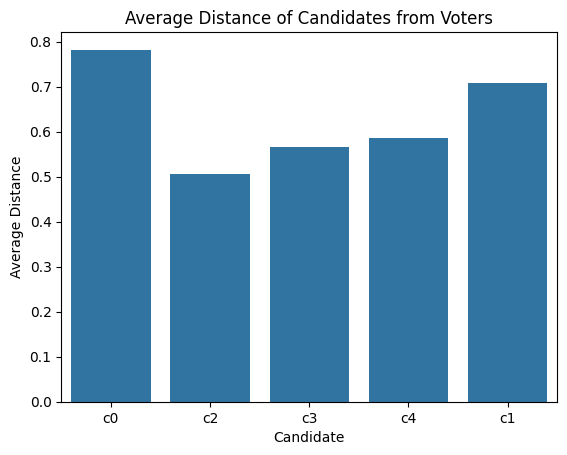

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Plot the average distance of each candidate from the voters in a bar graph
def plot_candidate_distances(model):
    distances = []
    candidates = [c for c in model.schedule.agents if isinstance(c, CandidateAgent)]

    for candidate in candidates:
        dist = np.mean([abs(voter.political_leaning - candidate.political_position) for voter in model.schedule.agents if isinstance(voter, VoterAgent)])
        distances.append((candidate.unique_id, dist))

    df = pd.DataFrame(distances, columns=["Candidate", "Average Distance"])
    sns.barplot(x="Candidate", y="Average Distance", data=df)
    plt.title("Average Distance of Candidates from Voters")
    plt.show()

# Call the function to plot the distances
plot_candidate_distances(model)
